In [ ]:
# this code is to produce PSDs, analysis, and the plots from lists of arrays of separated noise and event signals
# combined with csvCleaner into one larger script to run the analysis for the total outputs and inputs this should all work together

In [2]:
# also, want to save plotting responsibility for main script but will include matplot in this notebook for testing purposes

In [3]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [131]:
# first, for testing, we need to make said array of arrays
# it wont matter if we think this is noise or event, will work to test pipe all the same
# will be at 100 Hz, but will not *have* to be

timeGrid = np.arange(1443,3678,0.01)
noiseTimeGrid = []
for i in range(len(timeGrid)):
    diff = np.random.normal(0,0.005) # +- ~ 0.001 seconds, 10%
    noiseTimeGrid.append(timeGrid[i] + diff)
noiseTimeGrid = np.array(noiseTimeGrid)

noiseSignalA = 0.5 * np.sin(40*noiseTimeGrid/(2*np.pi))
noiseSignalB = 0.5 * np.sin(100*noiseTimeGrid/(2*np.pi))
noiseSignalC = 0.5 * np.sin(300*noiseTimeGrid/(2*np.pi))
noiseSignal1 = noiseSignalA + noiseSignalB
noiseSignal2 = (noiseSignalA + noiseSignalC)[10000:-10000]
noiseSignal3 = (noiseSignalB + noiseSignalC)[40000:-40000]

In [132]:
# plt.plot(timeGrid,noiseSignal1)
# plt.xlabel('time (s)')
# plt.ylabel('signal')
# plt.show()

In [133]:
noiseArrs = []
noiseArrs.append(noiseSignal1)
noiseArrs.append(noiseSignal2)
noiseArrs.append(noiseSignal3)
noiseArrs

[array([ 0.65061843,  0.71580095,  0.75667415, ...,  0.18443489,
         0.01108174, -0.22274716], shape=(223500,)),
 array([0.71783488, 0.61751416, 0.17220439, ..., 0.99381863, 0.6169449 ,
        0.47000832], shape=(203500,)),
 array([0.72796789, 0.74243465, 0.74407482, ..., 0.18760161, 0.07699373,
        0.01283483], shape=(143500,))]

In [134]:
# ok, now we start writing code that will actually be in the script
# first thing is to define some globals that will be overwritten by the larger script, but are good defaults if needed

defFreq = 100
defNper = 300

In [135]:
# now we gotta initialize dictionaries for frequencies
# freqDict needs to contain all of the different sampling frequencies we want, remember PSD can probe to sampFreq/2
freqDict = {
    f'freq{defFreq}':defFreq,
    f'freq{int(defFreq/2)}':defFreq/2,
    f'freq{int(defFreq/4)}':defFreq/4,
    f'freq{int(defFreq/10)}':defFreq/10,
    }

In [136]:
freqDict

{'freq100': 100, 'freq50': 50.0, 'freq25': 25.0, 'freq10': 10.0}

In [137]:
100 / freqDict['freq50']

2.0

In [138]:
def downSamp(nArr = noiseArrs,fd=freqDict):
    noiseDict = {}
    for label in fd.keys():
        f = fd[label]
        skipNum = int(defFreq / f)
        # print(type(skipNum))
        noiseDict[label] = []
        for i in range(len(nArr)):
            downArr = nArr[i][::skipNum]
            noiseDict[label].append(downArr)
    return noiseDict

In [139]:
noiseDict = downSamp()

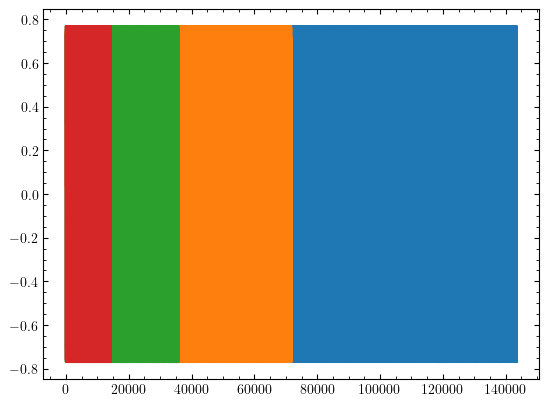

In [140]:
# downsampling works
plt.plot(noiseDict['freq100'][2])
plt.plot(noiseDict['freq50'][2])
plt.plot(noiseDict['freq25'][2])
plt.plot(noiseDict['freq10'][2])

In [141]:
noiseDict

{'freq100': [array([ 0.65061843,  0.71580095,  0.75667415, ...,  0.18443489,
          0.01108174, -0.22274716], shape=(223500,)),
  array([0.71783488, 0.61751416, 0.17220439, ..., 0.99381863, 0.6169449 ,
         0.47000832], shape=(203500,)),
  array([0.72796789, 0.74243465, 0.74407482, ..., 0.18760161, 0.07699373,
         0.01283483], shape=(143500,))],
 'freq50': [array([0.65061843, 0.75667415, 0.79636748, ..., 0.3795657 , 0.1811127 ,
         0.01108174], shape=(111750,)),
  array([ 0.71783488,  0.17220439, -0.17735162, ...,  0.81534325,
          0.95521171,  0.6169449 ], shape=(101750,)),
  array([0.72796789, 0.74407482, 0.27560604, ..., 0.71500724, 0.39177242,
         0.07699373], shape=(71750,))],
 'freq25': [array([0.65061843, 0.79636748, 0.74817693, ..., 0.53592405, 0.46016046,
         0.1811127 ], shape=(55875,)),
  array([ 0.71783488, -0.17735162,  0.16973194, ..., -0.02967818,
          0.29994968,  0.95521171], shape=(50875,)),
  array([ 0.72796789,  0.27560604, -0.75

In [142]:
# now to actually make the PSDs
def makePSD(dict = noiseDict,fDict = freqDict):
    PSDDict = {}
    fGridDict = {}
    for label in fDict.keys():
        list = dict[label]
        PSDDict[label] = []
        fGridDict[label] = []
        for i in range(len(list)):
            fGrid,psd = welch(list[i],fs=freqDict[label],nperseg=defNper)
            PSDDict[label].append(psd)
            fGridDict[label].append(fGrid)
    
    return PSDDict,fGridDict

In [143]:
PSDDict,fGridDict = makePSD()

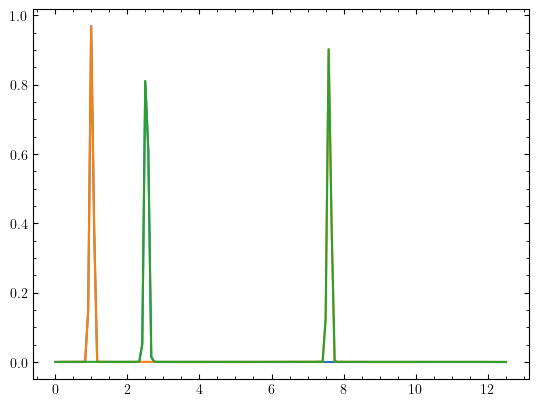

In [170]:
plt.plot(fGridDict['freq25'][0],PSDDict['freq25'][0])
plt.plot(fGridDict['freq25'][1],PSDDict['freq25'][1])
plt.plot(fGridDict['freq25'][2],PSDDict['freq25'][2])

In [162]:
np.array(PSDDict['freq25'])[0]

array([2.77599354e-04, 1.88417314e-04, 6.90216013e-05, 6.90270345e-05,
       7.21678231e-05, 7.11253806e-05, 7.35701387e-05, 7.38924677e-05,
       7.30555746e-05, 1.00139803e-04, 4.43455757e-04, 1.47327493e-01,
       9.68840078e-01, 3.83401455e-01, 1.24462607e-03, 1.33752249e-04,
       8.90019302e-05, 8.01577343e-05, 7.39864530e-05, 6.98162690e-05,
       6.84807011e-05, 7.19460404e-05, 7.53673301e-05, 7.77375867e-05,
       7.52584363e-05, 7.20944676e-05, 8.82432216e-05, 1.41154521e-04,
       7.71703329e-04, 5.14076322e-02, 8.09081931e-01, 6.13614088e-01,
       1.43657079e-02, 4.60783760e-04, 1.19043226e-04, 8.45380455e-05,
       8.57173316e-05, 7.98911227e-05, 7.27520601e-05, 7.58252097e-05,
       6.53885944e-05, 7.38920979e-05, 7.67871249e-05, 6.88405990e-05,
       6.83443126e-05, 7.54547802e-05, 7.36981080e-05, 7.82355052e-05,
       7.84908770e-05, 7.45421116e-05, 7.76348902e-05, 7.43271918e-05,
       7.31496764e-05, 7.83285782e-05, 8.04333558e-05, 7.95243594e-05,
      

In [174]:
# now we want to average across arrays per frequency sample
def PSDAverage(dict=PSDDict,fdict=fGridDict):
    PSDAvgDict = {}
    fAvgDict = {} # fGrid should be same across all list indices, but we condense so i can stop writing them
    for label in PSDDict.keys():
        PSDSum = np.sum(np.array(dict[label]),axis=0)
        fSum = np.sum(np.array(fdict[label]),axis=0)
        # print(PSDSum)
        PSDAvgDict[label] = PSDSum / len(dict[label])
        fAvgDict[label] = fSum / len(fdict[label])
    return PSDAvgDict,fAvgDict


In [175]:
avg,favg = PSDAverage()

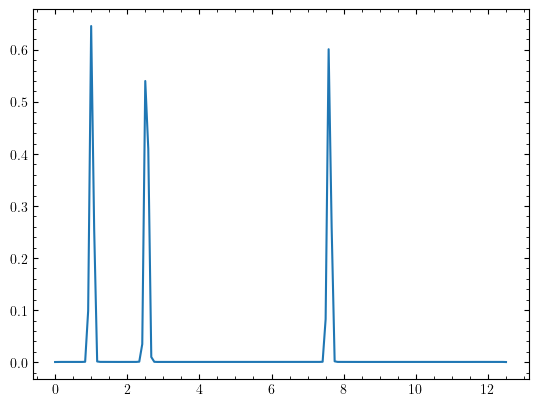

In [176]:
plt.plot(favg['freq25'],avg['freq25'])